In [3]:
!pip install pandas matplotlib

  Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached numpy-2.5.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.0 MB/s  0:00:00 eta 0:00:01
Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("NovaMarket_datos_crudos.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_pedido                  620 non-null    str    
 1   id_cliente                 620 non-null    str    
 2   fecha_compra               620 non-null    str    
 3   canal                      620 non-null    str    
 4   ciudad                     589 non-null    str    
 5   codigo_postal              620 non-null    int64  
 6   categoria_producto         620 non-null    str    
 7   producto                   620 non-null    str    
 8   precio                     599 non-null    float64
 9   unidades                   620 non-null    int64  
 10  edad_cliente               620 non-null    int64  
 11  correo                     516 non-null    str    
 12  nivel_satisfaccion         574 non-null    str    
 13  fecha_actualizacion_stock  620 non-null    str    
dtypes: fl

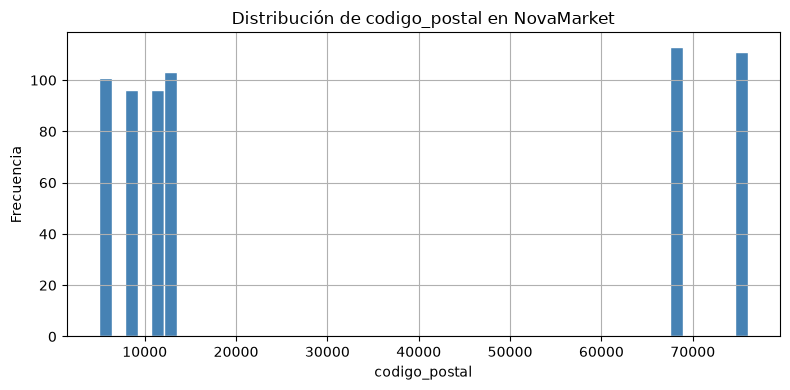

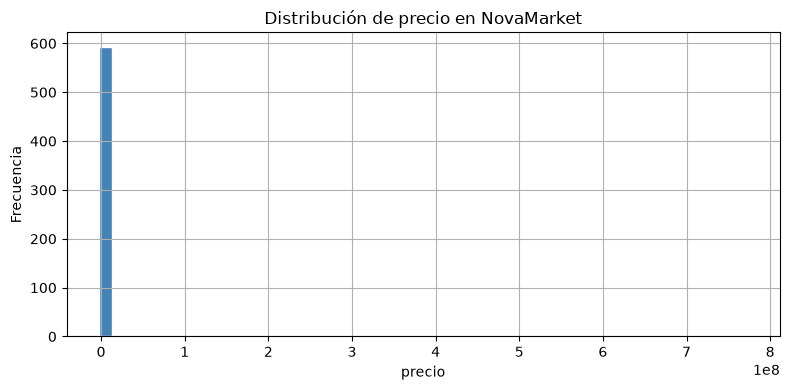

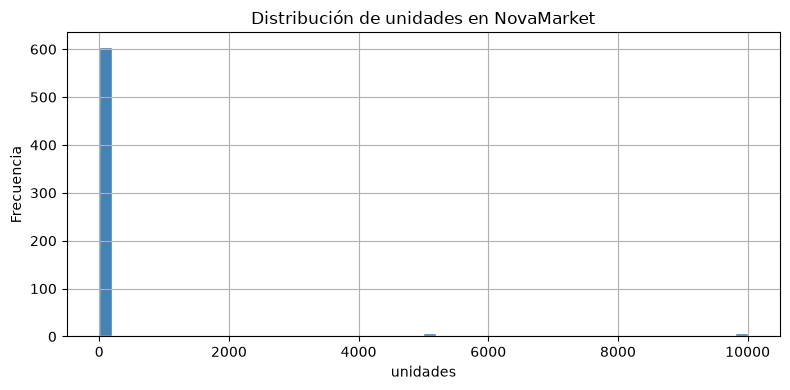

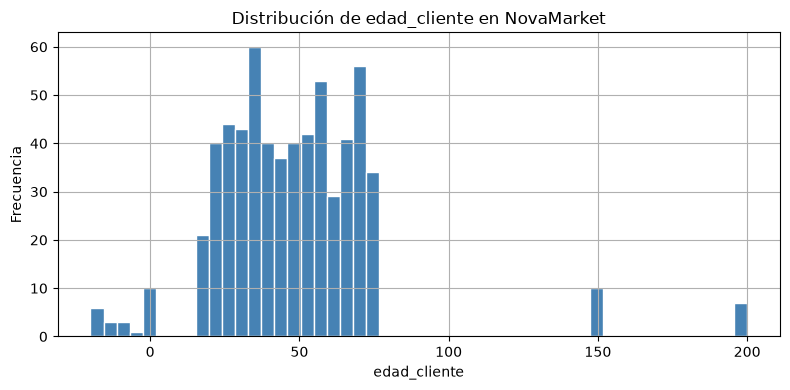

In [17]:
# Columnas numericas: histogramas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    df[col].dropna().hist(bins=50, color="steelblue", edgecolor="white")
    plt.title(f"Distribución de {col} en NovaMarket")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

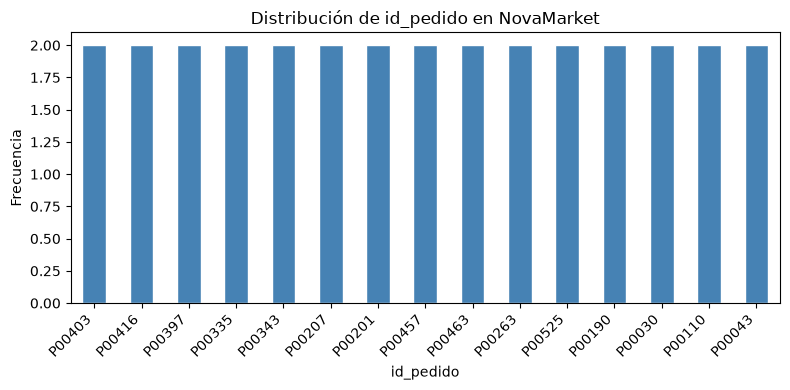

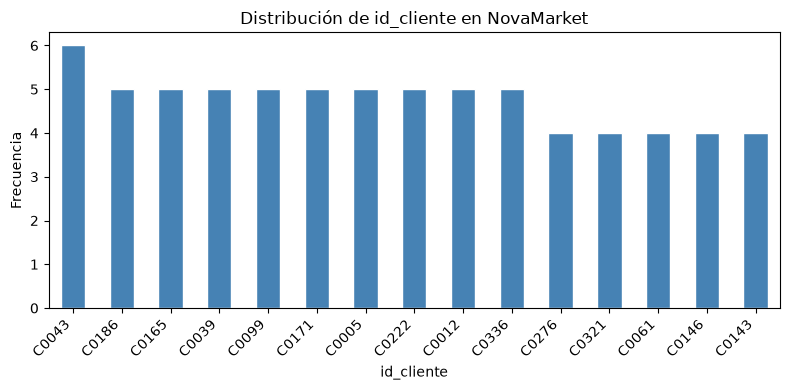

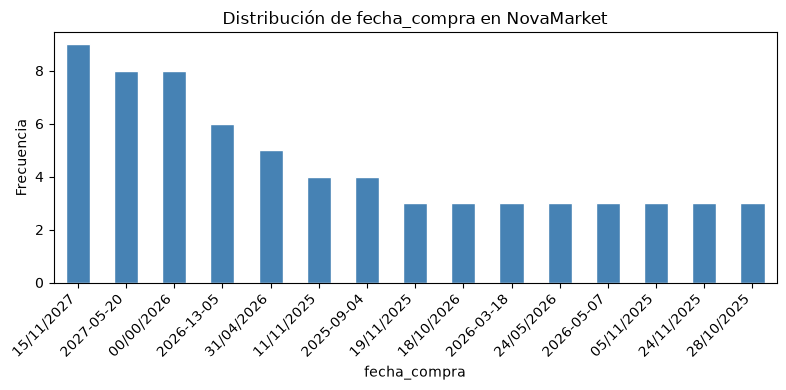

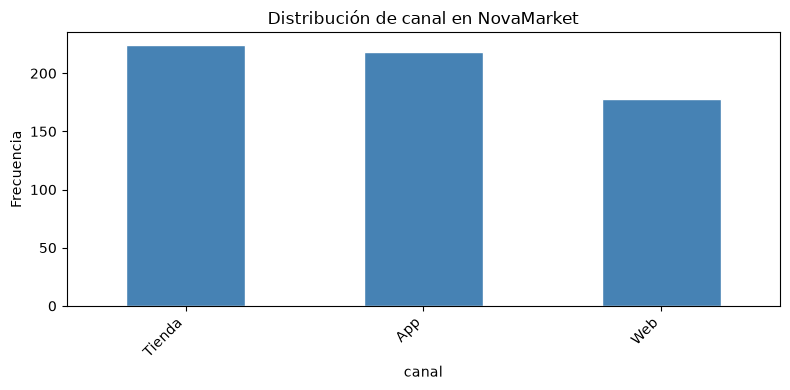

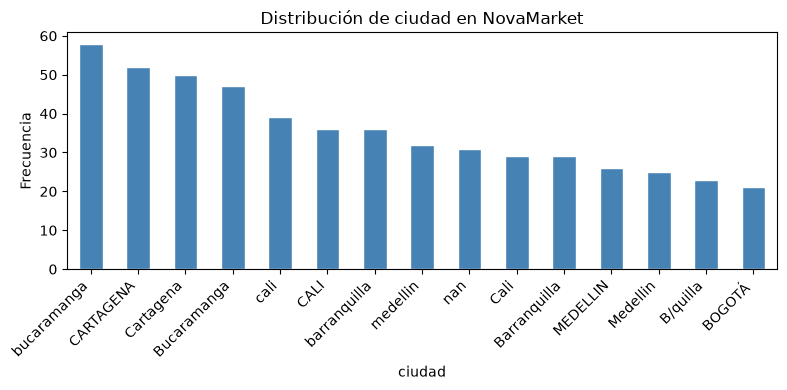

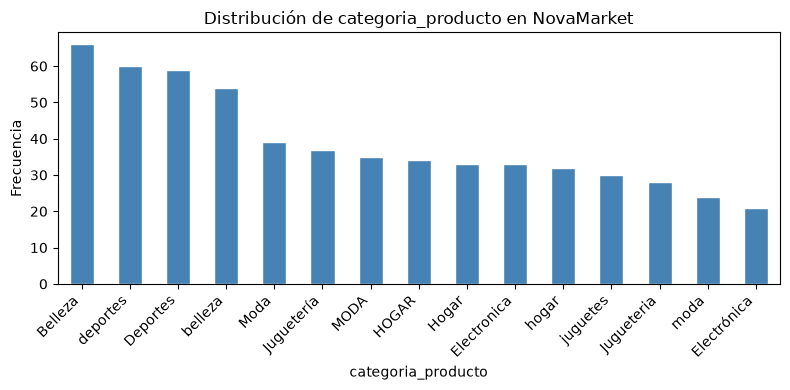

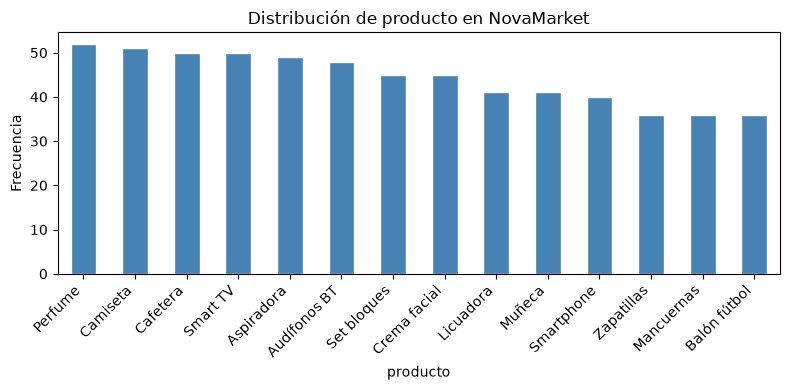

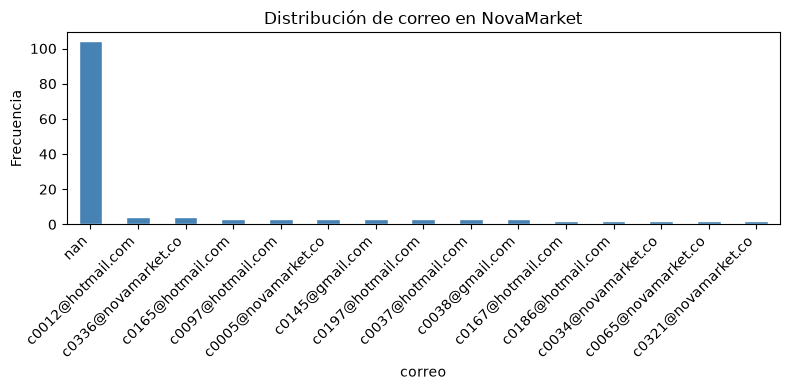

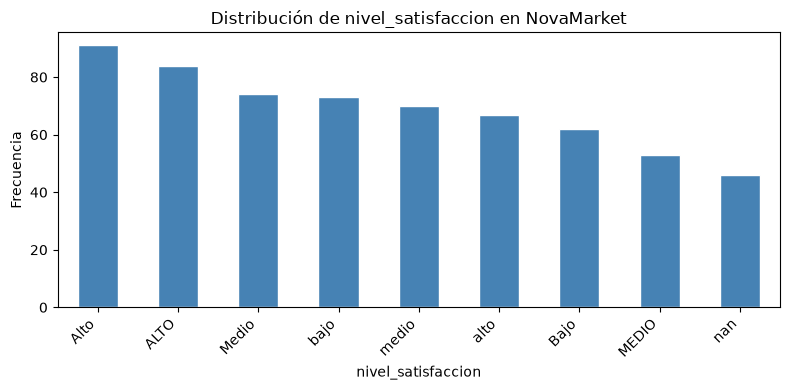

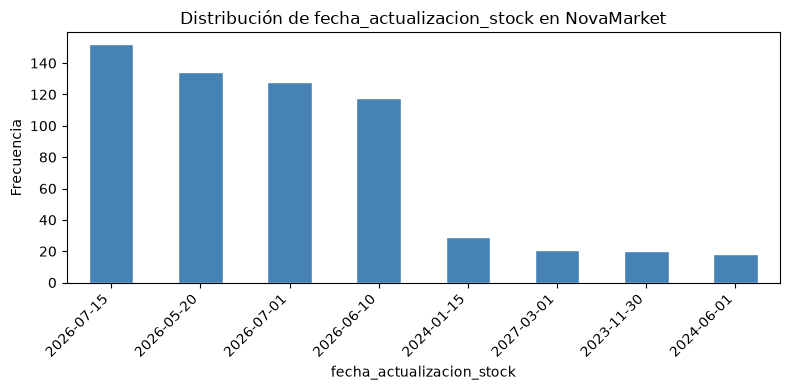

In [18]:
# Columnas categoricas/texto: graficos de barras
columnas_categoricas = df.select_dtypes(include=["object", "string"]).columns

for col in columnas_categoricas:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).head(15).plot(
        kind="bar",
        color="steelblue",
        edgecolor="white"
    )
    plt.title(f"Distribución de {col} en NovaMarket")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

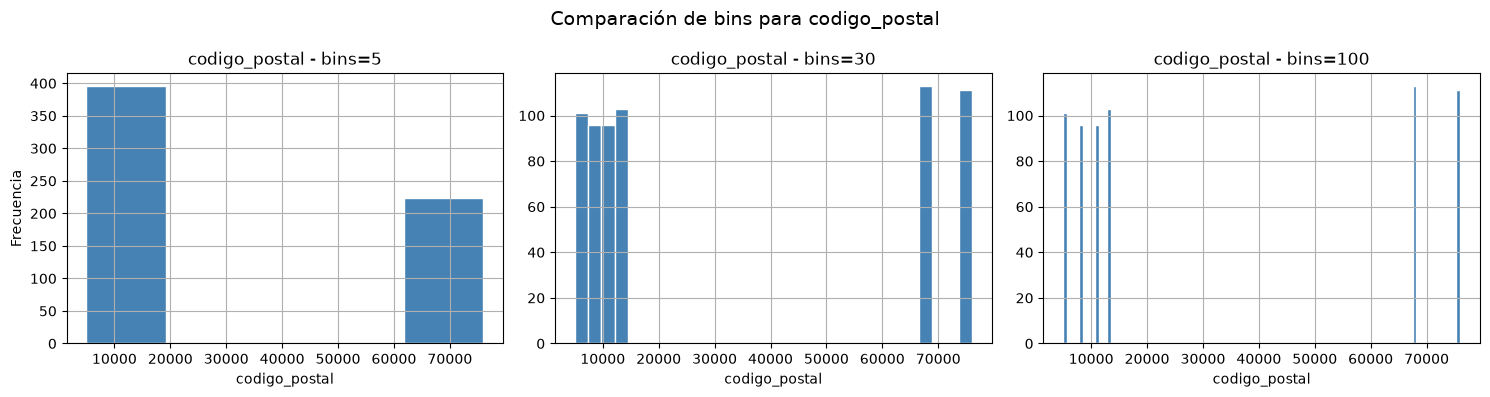

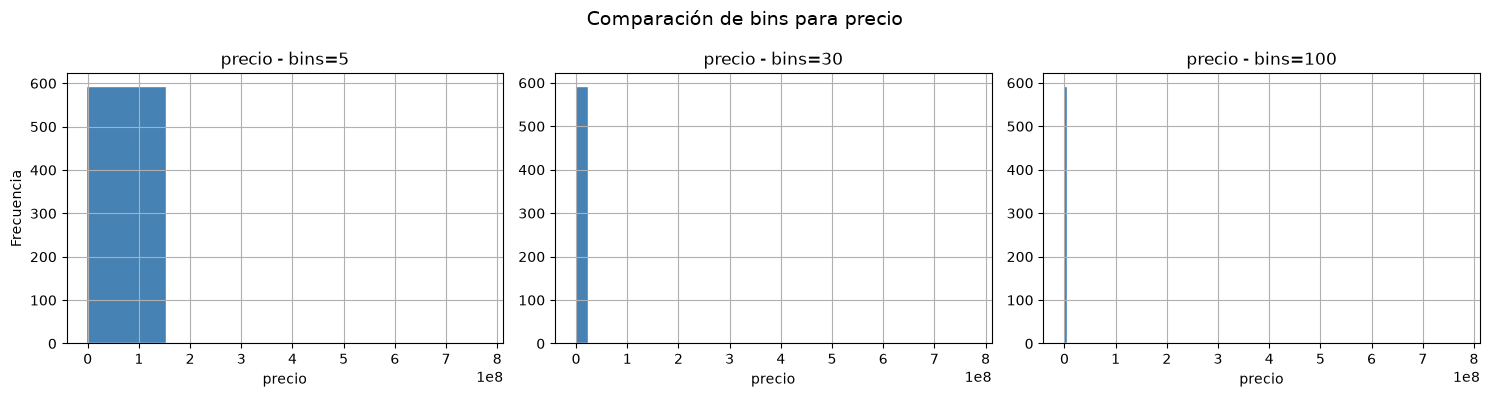

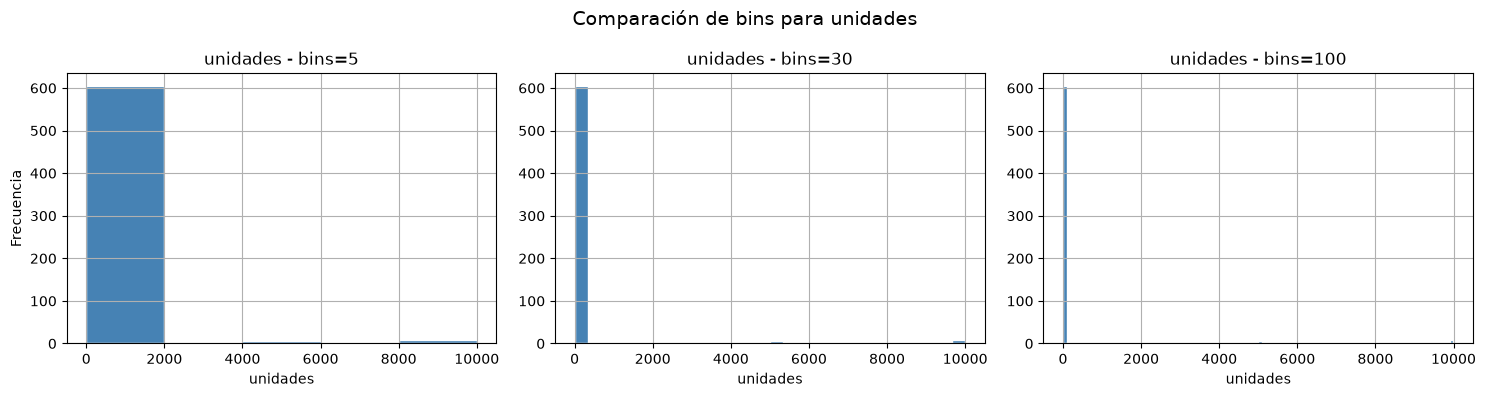

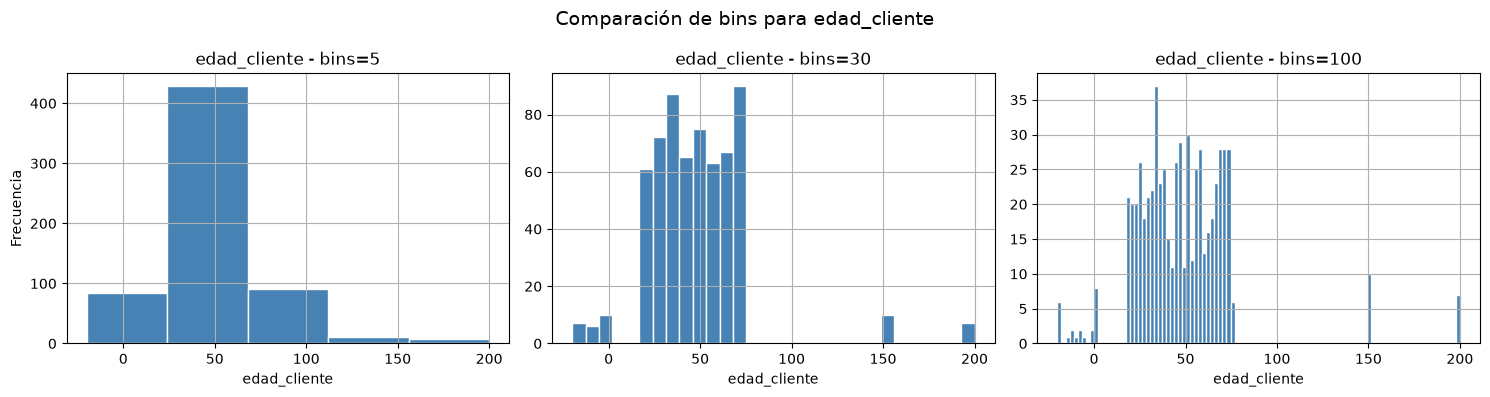

In [19]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

for col in columnas_numericas:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    df[col].dropna().hist(bins=5, ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title(f"{col} - bins=5")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    df[col].dropna().hist(bins=30, ax=axes[1], color="steelblue", edgecolor="white")
    axes[1].set_title(f"{col} - bins=30")
    axes[1].set_xlabel(col)

    df[col].dropna().hist(bins=100, ax=axes[2], color="steelblue", edgecolor="white")
    axes[2].set_title(f"{col} - bins=100")
    axes[2].set_xlabel(col)

    plt.suptitle(f"Comparación de bins para {col}", fontsize=14)
    plt.tight_layout()
    plt.show()


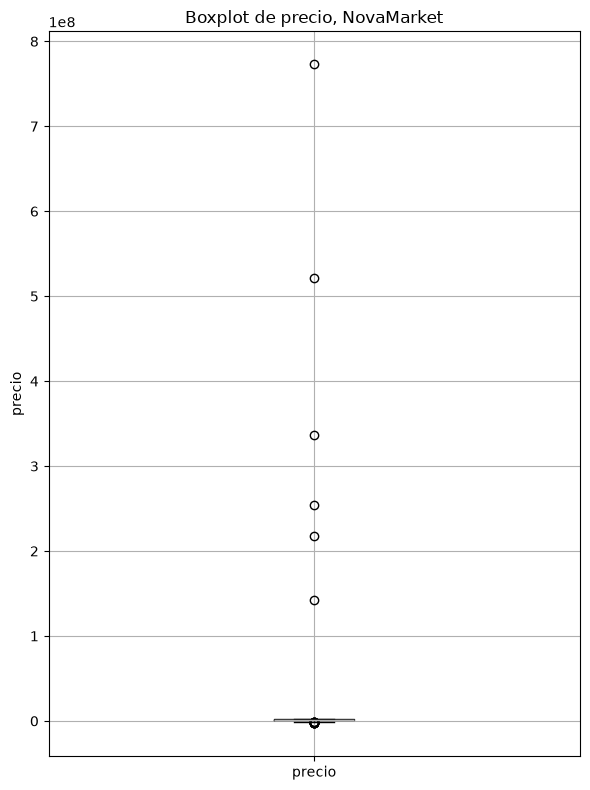

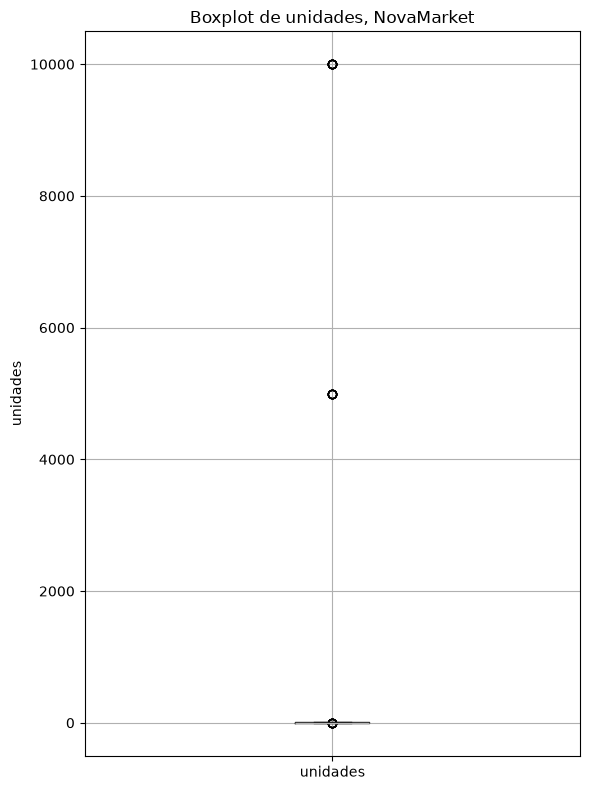

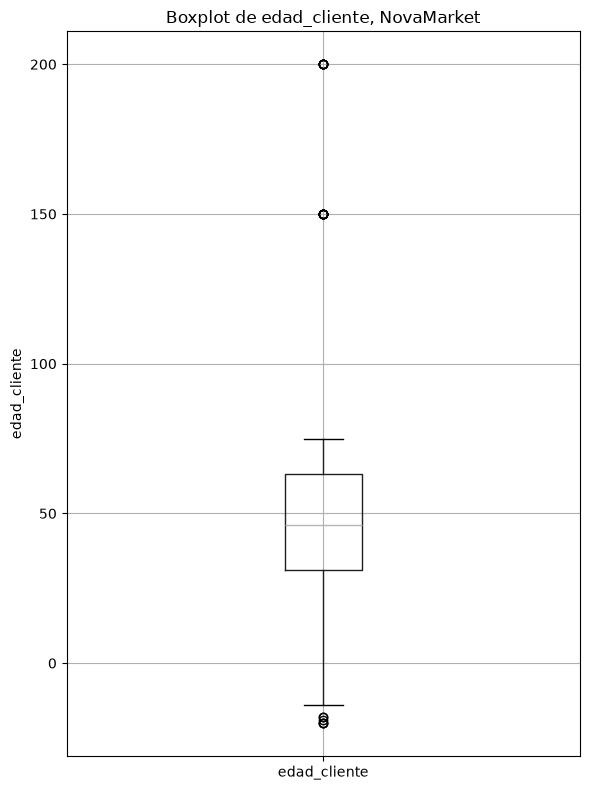

In [21]:
columnas_boxplot = ["precio", "unidades", "edad_cliente"]

for col in columnas_boxplot:
    plt.figure(figsize=(6, 8))
    df.boxplot(column=col, vert=True)

    plt.title(f"Boxplot de {col}, NovaMarket")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

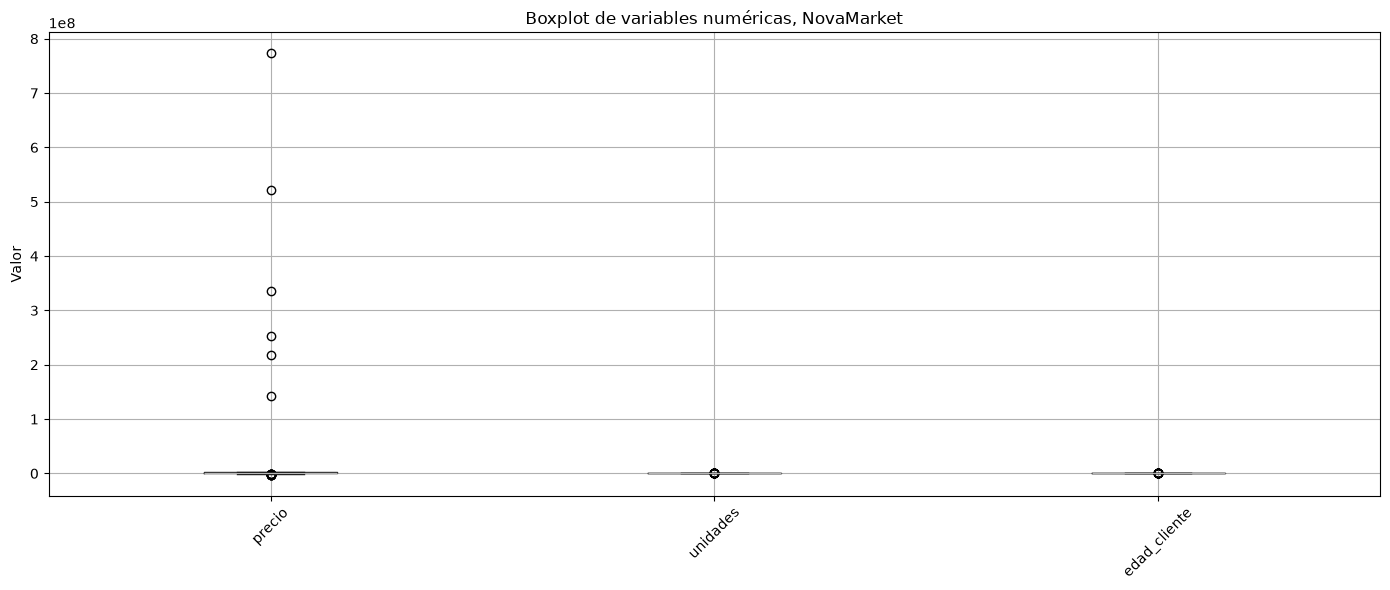

In [22]:
# Boxplot de variables numéricas relevantes a la vez
columnas_numericas = df.select_dtypes(include="number").columns.tolist()

# Quitar identificadores o códigos que no se interpretan como variables continuas
columnas_excluir = ["id_venta", "codigo_postal"]
columnas_boxplot = [col for col in columnas_numericas if col not in columnas_excluir]

df[columnas_boxplot].boxplot(figsize=(14, 6), rot=45)

plt.title("Boxplot de variables numéricas, NovaMarket")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

In [23]:
columnas_numericas = df.select_dtypes(include="number").columns.tolist()

# Quitar columnas que son códigos/identificadores
columnas_excluir = ["id_venta", "codigo_postal"]
columnas_analisis = [col for col in columnas_numericas if col not in columnas_excluir]

for col in columnas_analisis:
    datos = df[col].dropna()

    media = datos.mean()
    mediana = datos.median()
    skewness = datos.skew()

    print(f"\nVariable: {col}")
    print(f"Media: {media:.2f} | Mediana: {mediana:.2f}")

    if media > mediana:
        print("Sesgo positivo (a la derecha).")
    elif media < mediana:
        print("Sesgo negativo (a la izquierda).")
    else:
        print("Distribución aproximadamente simétrica.")

    print(f"Skewness: {skewness:.2f}")


Variable: precio
Media: 4888703.29 | Mediana: 1178666.00
Sesgo positivo (a la derecha).
Skewness: 13.90

Variable: unidades
Media: 188.68 | Mediana: 3.00
Sesgo positivo (a la derecha).
Skewness: 7.07

Variable: edad_cliente
Media: 48.01 | Mediana: 46.00
Sesgo positivo (a la derecha).
Skewness: 2.08


In [24]:
columnas_numericas = df.select_dtypes(include="number").columns.tolist()

columnas_excluir = ["id_venta", "codigo_postal"]
columnas_analisis = [col for col in columnas_numericas if col not in columnas_excluir]

asimetria = df[columnas_analisis].skew()

for col, valor in asimetria.items():
    if valor > 0:
        tipo = "sesgo positivo (a la derecha)"
    elif valor < 0:
        tipo = "sesgo negativo (a la izquierda)"
    else:
        tipo = "distribución aproximadamente simétrica"

    print(f"{col}: {valor:.2f} -> {tipo}")

precio: 13.90 -> sesgo positivo (a la derecha)
unidades: 7.07 -> sesgo positivo (a la derecha)
edad_cliente: 2.08 -> sesgo positivo (a la derecha)
